In [ ]:
# Cell 1: Imports and global setup

import os
import gc
import time
import traceback

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

import sys
sys.path.append(".")

from core.design_space import DesignSpace
from core.truth_interface import TruthModelEvaluator
from core.gp_models import GPModelManager
from core.acquisition_functions import AcquisitionFunctionManager
from core.agent_manager import BOAgent, ResourceEvent
from core.logging_utils import LoggingManager
from core.visualization import VisualizationManager

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.double

In [ ]:
# Cell 2: Problem configuration for Ti–V–Nb–Mo–Hf–Ta–W

# Design space (7D simplex with per-element bounds)
COMPONENTS = [
    ("Ti", 0.0,   0.35),
    ("V",  0.0,   0.50),
    ("Nb", 0.225, 0.675),
    ("Mo", 0.0,   0.125),
    ("Hf", 0.0,   0.125),
    ("Ta", 0.0,   0.45),
    ("W",  0.0,   0.125),
]
STEP = 0.05
SEED = 256

design_space = DesignSpace(components=COMPONENTS, step=STEP, seed=SEED)
bounds_np = design_space.get_bounds()  # (2, 7)
bounds_t = torch.tensor(bounds_np, dtype=DTYPE, device=DEVICE)

# Truth model (RF + scalers)
MODEL_PATH = "models/TiVNbMoHfTaW_Max_S_Max_TCond/RFR_best_model.pkl"
X_SCALER_PATH = "models/TiVNbMoHfTaW_Max_S_Max_TCond/x_scaler.pkl"
Y_SCALER_PATH = "models/TiVNbMoHfTaW_Max_S_Max_TCond/y_scaler.pkl"

# RF outputs: [ThermCond, SConf]
def postprocess_outputs(preds_raw: np.ndarray) -> np.ndarray:
    therm_cond = preds_raw[:, 0]
    sconf = preds_raw[:, 1]
    return np.column_stack([sconf, therm_cond])

evaluator = TruthModelEvaluator(
    model_path=MODEL_PATH,
    x_scaler_path=X_SCALER_PATH,
    y_scaler_path=Y_SCALER_PATH,
    postprocess_outputs=postprocess_outputs,
)

OBJ1_NAME = "Configurational Entropy"           # Y[:,0]
OBJ2_NAME = "Therm Cond"                        # Y[:,1]

# Fixed global min/max from original RF training data
SCONF_MIN = 1.104704674
SCONF_MAX = 1.592615027
TC_MIN = 7.279877639
TC_MAX = 36.56773905

def score_fn(Y: np.ndarray) -> np.ndarray: # This is the scoring function used *generally* to show off optimization progress on the graph. It's not used in the actual optimization though.
    sconf = Y[:, 0]
    tcond = Y[:, 1]

    sconf_norm = (sconf - SCONF_MIN) / (SCONF_MAX - SCONF_MIN + 1e-12)
    tcond_norm = (tcond - TC_MIN) / (TC_MAX - TC_MIN + 1e-12)

    return sconf_norm * tcond_norm

SCORE_NAME = "ThermCond×Entropy (global-normalized)"

# BO config
INIT_N = 5
ITERS = 50

TOTAL_BUDGET = 5100.0
TOTAL_TIME = 51.0
COST_PER_POINT = 20.0
TIME_PER_ITERATION = 1.0

MC_SAMPLES = 64
POOL_SUBSAMPLE = 1024
TOTAL_BATCH_SIZE = 5

# Agent / LLM
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
AGENT_MODEL = "gpt-4o"
MAX_REASONING_STEPS = 3

PROBLEM_DESCRIPTION = """
Ti-V-Nb-Mo-Hf-Ta-W refractory alloy optimization.

Objectives:
- Maximize configurational entropy.
- Maximize room-temperature thermal conductivity (W/(mK)).

Input space: 7D compositions (Ti, V, Nb, Mo, Hf, Ta, W) summing to 1.0,
with element-specific bounds and grid step 0.025.

Take into account the options for the next candidate batch along with the optimization progress. You should balance exploration and optimization given the qEHVI and Entropy for each option to best reach your goal within the time limit and budget constraints. Think critically about what action should be taken given each constraint. 
"""

# Logging / visualization
LOG_DIR = "results"
EXPERIMENT_NAME = "TiVNbMoHfTaW_Entropy-Budget-20"
CREATE_VIS = True
CREATE_GIF = True

[DesignSpace] Generated 529922 valid compositions for 7 components: Ti, V, Nb, Mo, Hf, Ta, W
[TruthEvaluator] Loading model from models/TiVNbMoHfTaW_Max_S_Max_TCond/RFR_best_model.pkl
[TruthEvaluator] Model loaded successfully
[TruthEvaluator] RF outputs: 2


In [ ]:
# Cell 3: GP, acquisition manager, agent, logger, visualization

gp_manager = GPModelManager(bounds=bounds_t, use_priors=False)
acq_manager = AcquisitionFunctionManager(bounds=bounds_t)

agent_log_dir = os.path.join(LOG_DIR, EXPERIMENT_NAME, "agent_logs")
os.makedirs(agent_log_dir, exist_ok=True)

agent = BOAgent(
    api_key=OPENAI_API_KEY,
    model=AGENT_MODEL,
    log_dir=agent_log_dir,
    max_reasoning_steps=MAX_REASONING_STEPS,
    temperature=0.7,
    problem_description=PROBLEM_DESCRIPTION,
    obj1_name=OBJ1_NAME,
    obj2_name=OBJ2_NAME,
)

# Example: no events by default; you can add ResourceEvent instances here
events: list[ResourceEvent] = []
budget_for_two_batches = 2 * TOTAL_BATCH_SIZE * COST_PER_POINT

events.append(
    ResourceEvent(
        iteration=20,
        event_type="budget_change",
        description=f"Budget reduced at iter 20 to afford only 2 more iterations "
                    f"(2 × {TOTAL_BATCH_SIZE} × ${COST_PER_POINT:.2f})",
        modifier=lambda current_budget, b2=budget_for_two_batches: b2
        # We set absolute budget to b2, independent of current_budget.
        # If you prefer proportional, use: lambda x: min(x, b2)
    )
)

for ev in events:
    agent.add_event(ev)

exp_dir = os.path.join(LOG_DIR, EXPERIMENT_NAME)
os.makedirs(exp_dir, exist_ok=True)
logger = LoggingManager(exp_dir, EXPERIMENT_NAME)

vis_manager = None
if CREATE_VIS:
    try:
        vis_manager = VisualizationManager(log_dir=exp_dir, design_space=design_space, experiment_name=EXPERIMENT_NAME)
    except Exception as e:
        print(f"[NB] Visualization disabled: {e}")
        vis_manager = None

[Logger] Initialized logging in results\TiVNbMoHfTaW_Entropy-Budget-20
[Logger] Files:
  - Convergence: results\TiVNbMoHfTaW_Entropy-Budget-20\TiVNbMoHfTaW_Entropy-Budget-20_convergence.csv
  - Options: results\TiVNbMoHfTaW_Entropy-Budget-20\TiVNbMoHfTaW_Entropy-Budget-20_options.csv
  - Evaluations: results\TiVNbMoHfTaW_Entropy-Budget-20\TiVNbMoHfTaW_Entropy-Budget-20_evaluations.csv
[Viz] Using full design space (529922 points) for visualization
[Viz] Setup affine projection: projected 529922 points
[Viz] Cached visualization space on CPU: torch.Size([529922, 7])
[Viz] Initialized visualization in results\TiVNbMoHfTaW_Entropy-Budget-20\visualizations
[Viz] Experiment name: TiVNbMoHfTaW_Entropy-Budget-20
[Viz] Dimension d=7, labels=['Ti', 'V', 'Nb', 'Mo', 'Hf', 'Ta', 'W']


In [ ]:
# Cell 4: Visualize objective fields using the RF truth model

def truth_eval_Y(X: np.ndarray) -> np.ndarray:
    result = evaluator.evaluate(X)
    return result.y

if CREATE_VIS and vis_manager is not None:
    try:
        truth_plots = vis_manager.plot_objectives_from_evaluator(
            evaluator=truth_eval_Y,
            obj_names=[OBJ1_NAME, OBJ2_NAME],
            filename_prefix="truth"
        )
        print("Truth objective plots:", truth_plots)
    except Exception as e:
        print("Could not plot truth objectives.")
        print("Exception:", repr(e))
        traceback.print_exc()

[Viz] Created scalar field plot: results\TiVNbMoHfTaW_Entropy-Budget-20\visualizations\truth_0_Configurational_Entropy.png
[Viz] Created scalar field plot: results\TiVNbMoHfTaW_Entropy-Budget-20\visualizations\truth_1_Therm_Cond.png
Truth objective plots: ['results\\TiVNbMoHfTaW_Entropy-Budget-20\\visualizations\\truth_0_Configurational_Entropy.png', 'results\\TiVNbMoHfTaW_Entropy-Budget-20\\visualizations\\truth_1_Therm_Cond.png']


In [ ]:
# Cell 5: Agent configures GP kernel

print("\n" + "=" * 80)
print("[NB] Agent configuring GP kernel...")
print("=" * 80)

kernel_code, kernel_reasoning = agent.configure_gp_kernel(use_priors=False)

if kernel_code:
    print("[NB] Agent requested custom kernel (not implemented). Using default.")
else:
    print("[NB] Agent selected default kernel.")


[NB] Agent configuring GP kernel...

[Agent] Configuring GP Kernel

[Agent] Reasoning step 1/3...

REASONING: 
1. **Kernel Properties for Input Space**: The optimization problem involves a 7D compositional space with constraints that the compositions sum to 1 and are bounded by specific limits. The kernel should be capable of capturing smooth variations in the objective functions with respect to small changes in composition, as well as handling the bounded domain effectively. 

2. **Default Kernel Sufficiency**: The RBF (Radial Basis Function) and Matern kernels are typically good defaults for Gaussian Processes because they are flexible, smooth, and can capture a wide range of functional forms. The RBF kernel assumes a very smooth function, while the Matern kernel can be tuned to allow for rougher functions, which might be more appropriate if the objectives exhibit abrupt changes. Given the lack of prior data and understanding of the ruggedness of the objective landscape, starting wi

In [ ]:
# Cell 6: Initial random sampling and evaluation

torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"\n[NB] Initializing with {INIT_N} random samples from simplex")
X0_np = design_space.sample(INIT_N, method="random")
result0 = evaluator.evaluate(X0_np)
Y0_np = result0.y  # [entropy, therm_cond]

X = torch.tensor(X0_np, dtype=DTYPE, device=DEVICE)
Y = torch.tensor(Y0_np, dtype=DTYPE, device=DEVICE)

initial_budget_spent = INIT_N * COST_PER_POINT
initial_time_spent = TIME_PER_ITERATION
budget_remaining = TOTAL_BUDGET - initial_budget_spent
time_remaining = TOTAL_TIME - initial_time_spent

print(f"[NB] Initial sampling used: ${initial_budget_spent:.2f} / {initial_time_spent:.1f} weeks")
print(f"[NB] Remaining: ${budget_remaining:.2f} / {time_remaining:.1f} weeks")

logger.log_iteration(
    iteration=0,
    X_history=X.cpu().numpy(),
    Y_history=Y.cpu().numpy(),
    n_new_points=INIT_N,
    strategy=agent,
    timing=0.0,
    extra_info={"note": "initial_sampling", "agent_kernel_reasoning": kernel_reasoning},
    acquisition_data=None,
    score_fn=score_fn,
    obj1_name=OBJ1_NAME,
    obj2_name=OBJ2_NAME,
)

logger.log_evaluations(
    iteration=0,
    X_new=X0_np,
    Y_new=Y0_np,
    selection_info=None,
    score_fn=score_fn,
    obj1_name=OBJ1_NAME,
    obj2_name=OBJ2_NAME,
)


[NB] Initializing with 5 random samples from simplex
[NB] Initial sampling used: $100.00 / 1.0 weeks
[NB] Remaining: $5000.00 / 50.0 weeks
[Logger] Logged convergence for iteration 0
[Logger] Logged 5 evaluations for iteration 0


In [ ]:
# Cell 7: Main Bayesian Optimization loop

iteration = 0

while iteration < ITERS:
    if budget_remaining < COST_PER_POINT or time_remaining < TIME_PER_ITERATION:
        print(f"\n[NB] Stopping: insufficient budget (${budget_remaining:.2f}) or time ({time_remaining:.1f} weeks)")
        break

    iteration += 1
    iter_start = time.perf_counter()

    budget_remaining, time_remaining, COST_PER_POINT, event_msgs = agent.process_iteration_events(
        iteration, budget_remaining, time_remaining, COST_PER_POINT
    )
    if event_msgs:
        print("\n" + "=" * 80)
        for msg in event_msgs:
            print(msg)
        print("=" * 80)

    print("\n" + "=" * 80)
    print(f"[NB] Iteration {iteration}/{ITERS}")
    print(f"[NB] Budget: ${budget_remaining:.2f} | Time: {time_remaining:.1f} weeks")
    print("=" * 80)

    print("[NB] Fitting MultiTaskGP model...")
    model = gp_manager.fit_model(X, Y)

    Y_np = Y.cpu().numpy()
    Y_for_pareto = torch.tensor(
        np.column_stack([-Y_np[:, 0], Y_np[:, 1]]),
        dtype=DTYPE,
        device=DEVICE,
    )
    pareto_Y, ref_point = acq_manager.compute_pareto_front(Y_for_pareto)

    if POOL_SUBSAMPLE is None:
        X_pool_np = design_space.space
    else:
        X_pool_np = design_space.sample(POOL_SUBSAMPLE, method="sobol")
    X_pool = torch.tensor(X_pool_np, dtype=DTYPE, device=DEVICE)

    print("[NB] Computing acquisition options...")
    allocation_options = acq_manager.compute_all_allocation_options(
        model=model,
        X_pool=X_pool,
        pareto_Y=pareto_Y,
        ref_point=ref_point,
        mc_samples=MC_SAMPLES,
    )

    print("[NB] Consulting LLM agent for resource allocation...")
    selected_idx, reasoning, selected_point_arrays = agent.select_resource_allocation(
        iteration=iteration,
        budget_remaining=budget_remaining,
        time_remaining=time_remaining,
        cost_per_point=COST_PER_POINT,
        time_per_point=TIME_PER_ITERATION,
        X_history=X.cpu().numpy(),
        Y_history=Y.cpu().numpy(),
        allocation_options=allocation_options,
        max_batch_size=TOTAL_BATCH_SIZE,
        score_fn=score_fn,
    )

    if selected_point_arrays:
        X_next_np = np.vstack(selected_point_arrays)
    else:
        print("[NB] Agent selected no points; using balanced option (index 2) as fallback.")
        batch = allocation_options.qehvi_batches[2]
        parts = []
        if batch.points.size > 0:
            parts.append(batch.points)
        if batch.explore_points.size > 0:
            parts.append(batch.explore_points)
        X_next_np = np.vstack(parts) if parts else design_space.sample(1, method="random")

    print(f"[NB] Evaluating {len(X_next_np)} selected points...")
    result_next = evaluator.evaluate(X_next_np)
    Y_next_np = result_next.y

    X = torch.cat([X, torch.tensor(X_next_np, dtype=DTYPE, device=DEVICE)], dim=0)
    Y = torch.cat([Y, torch.tensor(Y_next_np, dtype=DTYPE, device=DEVICE)], dim=0)

    points_used = len(X_next_np)
    budget_spent = points_used * COST_PER_POINT
    time_spent = TIME_PER_ITERATION
    budget_remaining -= budget_spent
    time_remaining -= time_spent

    iter_time = time.perf_counter() - iter_start

    selected_batch = allocation_options.qehvi_batches[selected_idx]
    n_opt = selected_batch.batch_size
    n_exp = TOTAL_BATCH_SIZE - n_opt

    extra_info = {
        "agent_selected_option": selected_idx,
        "n_optimization": n_opt,
        "n_exploration": n_exp,
        "agent_reasoning": reasoning[:200] + "..." if len(reasoning) > 200 else reasoning,
        "budget_remaining": budget_remaining,
        "time_remaining": time_remaining,
        "budget_spent_this_iter": budget_spent,
        "time_spent_this_iter": time_spent,
    }

    logger.log_iteration(
        iteration=iteration,
        X_history=X.cpu().numpy(),
        Y_history=Y.cpu().numpy(),
        n_new_points=points_used,
        strategy=agent,
        timing=iter_time,
        extra_info=extra_info,
        acquisition_data=allocation_options,
        score_fn=score_fn,
        obj1_name=OBJ1_NAME,
        obj2_name=OBJ2_NAME,
    )

    logger.log_evaluations(
        iteration=iteration,
        X_new=X_next_np,
        Y_new=Y_next_np,
        selection_info=None,
        score_fn=score_fn,
        obj1_name=OBJ1_NAME,
        obj2_name=OBJ2_NAME,
    )

    if vis_manager is not None:
        vis_manager.create_iteration_plot(
            iteration=iteration,
            X_history=X.cpu().numpy(),
            Y_history=Y.cpu().numpy(),
            X_new=X_next_np,
            model=model,
            bounds=bounds_t,
            selection_info={"agent_option": selected_idx},
            score_fn=score_fn,
            score_name=SCORE_NAME,
            obj1_name=OBJ1_NAME,
            obj2_name=OBJ2_NAME,
        )

    scores_all = score_fn(Y.cpu().numpy())
    best_score = float(np.max(scores_all))
    print(f"\n[NB] Iteration {iteration} complete in {iter_time:.2f}s")
    print(f"[NB] Best {SCORE_NAME}: {best_score:.3f}")
    print(f"[NB] Remaining: ${budget_remaining:.2f} / {time_remaining:.1f} weeks")

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\n" + "=" * 80)
print("[NB] Optimization complete.")
print("=" * 80)


[NB] Iteration 1/50
[NB] Budget: $5000.00 | Time: 50.0 weeks
[NB] Fitting MultiTaskGP model...


c:\Users\Robert Robinson\Documents\resource-allocation\.venv\Lib\site-packages\linear_operator\utils\interpolation.py:71: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:656.)
  summing_matrix = cls(summing_matrix_indices, summing_matrix_values, size)


[NB] Computing acquisition options...
[AcqFn] Computing acquisition functions.
[AcqFn] Using 256 samples for qEHVI, 64 for MO-MESMO
[AcqFn] Computing top entropy reference points...

[AcqFn] Option 0: 5 exploit + 0 explore
  Optimizing qEHVI with q=5...
  → Entropy: 14.5359, QEHVI: 2.7193

[AcqFn] Option 1: 4 exploit + 1 explore
  Optimizing qEHVI with q=4...
  Optimizing MO-MESMO with q=1...
  ✗ MO-MESMO failed: NaN/Inf in acquisition values
  Using fallback: variance-based entropy sampling
  [Fallback] Entropy-based sampling in box defined by bounds
  → Entropy: 18.9848, QEHVI: 2.8470

[AcqFn] Option 2: 3 exploit + 2 explore
  Optimizing qEHVI with q=3...
  Optimizing MO-MESMO with q=2...
  ✗ MO-MESMO failed: NaN/Inf in acquisition values
  Using fallback: variance-based entropy sampling
  [Fallback] Entropy-based sampling in box defined by bounds
  → Entropy: 18.8172, QEHVI: 2.6790

[AcqFn] Option 3: 2 exploit + 3 explore
  Optimizing qEHVI with q=2...
  Optimizing MO-MESMO with q=3

c:\Users\Robert Robinson\Documents\resource-allocation\core\agent_manager.py:170: LangChainDeprecationWarning: Please see the migration guide at: https://python.langchain.com/docs/versions/migrating_memory/
  return ConversationBufferMemory(memory_key="chat_history", return_messages=True)



[Agent Analysis]:
## Key Decision Criteria

**1. Runway Assessment**:
   - Approx. iterations remaining: ~50
   - Approx. affordable points: ~250
   - Limiting factor: budget

**2. Progress Momentum**:
   - Total points: 5
   - Best score: 0.192
   - Trend (last 3 vs previous 3): N/A

**3. Best Observed Point**:
   - Configurational Entropy: 1.485
   - Therm Cond: 14.48
   - Coordinates: x_0=0.175, x_1=0.150, x_2=0.425, x_3=0.025, x_4=0.000, x_5=0.125, x_6=0.100


[Agent] Reasoning step 1/3...

REASONING:

1. **Runway and Budget Management**: We have a significant runway with approximately 50 iterations remaining and a budget that can accommodate about 250 points. This suggests we can afford to take an exploratory approach without immediate concern for budget depletion.

2. **Current Progress and Best Observed Point**: Since this is only the first iteration, there is no significant trend data available. The best observed point has a configurational entropy of 1.485 and thermal conduct

...

  → Entropy: 3.0056, QEHVI: 3.4906

[AcqFn] Option 1: 4 exploit + 1 explore
  Optimizing qEHVI with q=4...
  Optimizing MO-MESMO with q=1...
  ✗ MO-MESMO failed: NaN/Inf in acquisition values
  Using fallback: variance-based entropy sampling
  [Fallback] Entropy-based sampling in box defined by bounds
  → Entropy: 7.1526, QEHVI: 3.4834

[AcqFn] Option 2: 3 exploit + 2 explore
  Optimizing qEHVI with q=3...
  Optimizing MO-MESMO with q=2...
  ✗ MO-MESMO failed: NaN/Inf in acquisition values
  Using fallback: variance-based entropy sampling
  [Fallback] Entropy-based sampling in box defined by bounds
  → Entropy: 8.9955, QEHVI: 3.4830

[AcqFn] Option 3: 2 exploit + 3 explore
  Optimizing qEHVI with q=2...
  Optimizing MO-MESMO with q=3...
  ✗ MO-MESMO failed: NaN/Inf in acquisition values
  Using fallback: variance-based entropy sampling
  [Fallback] Entropy-based sampling in box defined by bounds
  → Entropy: 10.8050, QEHVI: 3.4705

[AcqFn] Option 4: 1 exploit + 4 explore
  Optimizing q

c:\Users\Robert Robinson\Documents\resource-allocation\.venv\Lib\site-packages\linear_operator\utils\cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


[NB] Computing acquisition options...
[AcqFn] Computing acquisition functions.
[AcqFn] Using 256 samples for qEHVI, 64 for MO-MESMO
[AcqFn] Computing top entropy reference points...

[AcqFn] Option 0: 5 exploit + 0 explore
  Optimizing qEHVI with q=5...
  → Entropy: -7.7354, QEHVI: 3.1604

[AcqFn] Option 1: 4 exploit + 1 explore
  Optimizing qEHVI with q=4...
  Optimizing MO-MESMO with q=1...
  ✗ MO-MESMO failed: NaN/Inf in acquisition values
  Using fallback: variance-based entropy sampling
  [Fallback] Entropy-based sampling in box defined by bounds
  → Entropy: -4.8251, QEHVI: 3.1605

[AcqFn] Option 2: 3 exploit + 2 explore
  Optimizing qEHVI with q=3...
  Optimizing MO-MESMO with q=2...
  ✓ MO-MESMO succeeded
  → Entropy: -8.3128, QEHVI: 3.2090

[AcqFn] Option 3: 2 exploit + 3 explore
  Optimizing qEHVI with q=2...
  Optimizing MO-MESMO with q=3...
  ✗ MO-MESMO failed: NaN/Inf in acquisition values
  Using fallback: variance-based entropy sampling
  [Fallback] Entropy-based samplin

c:\Users\Robert Robinson\Documents\resource-allocation\.venv\Lib\site-packages\linear_operator\utils\cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
c:\Users\Robert Robinson\Documents\resource-allocation\.venv\Lib\site-packages\linear_operator\utils\cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-07 to the diagonal
  warnings.warn(
c:\Users\Robert Robinson\Documents\resource-allocation\.venv\Lib\site-packages\linear_operator\utils\cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(
c:\Users\Robert Robinson\Documents\resource-allocation\.venv\Lib\site-packages\linear_operator\utils\cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-05 to the diagonal
  warnings.warn(
c:\Users\Robert Robinson\Documents\resource-allocation\.venv\Lib\site-packages\linear_operator\utils\cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-04 to the diagon

[NB] Computing acquisition options...
[AcqFn] Computing acquisition functions.
[AcqFn] Using 256 samples for qEHVI, 64 for MO-MESMO
[AcqFn] Computing top entropy reference points...

[AcqFn] Option 0: 5 exploit + 0 explore
  Optimizing qEHVI with q=5...
  → Entropy: 0.4206, QEHVI: 3.1302

[AcqFn] Option 1: 4 exploit + 1 explore
  Optimizing qEHVI with q=4...
  Optimizing MO-MESMO with q=1...
  ✓ MO-MESMO succeeded
  → Entropy: 1.5372, QEHVI: 3.0750

[AcqFn] Option 2: 3 exploit + 2 explore
  Optimizing qEHVI with q=3...
  Optimizing MO-MESMO with q=2...
  ✓ MO-MESMO succeeded
  → Entropy: -0.2900, QEHVI: 3.0637

[AcqFn] Option 3: 2 exploit + 3 explore
  Optimizing qEHVI with q=2...
  Optimizing MO-MESMO with q=3...
  ✓ MO-MESMO succeeded
  → Entropy: -0.5438, QEHVI: 2.9925

[AcqFn] Option 4: 1 exploit + 4 explore
  Optimizing qEHVI with q=1...
  Optimizing MO-MESMO with q=4...
  ✓ MO-MESMO succeeded
  → Entropy: -1.6044, QEHVI: 2.8949

[AcqFn] Option 5: 0 exploit + 5 explore
  Optimizin

In [ ]:
# Cell 8: Finalization, summary, and GIF

agent.save_global_memory()
print(f"[NB] Agent memory saved in {agent_log_dir}")

logger.finalize()

if vis_manager is not None and CREATE_GIF:
    vis_manager.create_gif(duration=2.0, gif_name=f"{EXPERIMENT_NAME}.gif")

summary = logger.get_summary_stats(obj1_name=OBJ1_NAME, obj2_name=OBJ2_NAME) if hasattr(logger, "get_summary_stats") else {}
print("\n[NB] Summary statistics:")
for k, v in summary.items():
    print(f"  {k}: {v}")

[NB] Agent memory saved in results\TiVNbMoHfTaW_Entropy-Budget-20\agent_logs
[Logger] Finalized logging for TiVNbMoHfTaW_Entropy-Budget-20
[Viz] Determining minimum image dimensions for GIF...
[Viz] Created GIF at results\TiVNbMoHfTaW_Entropy-Budget-20\TiVNbMoHfTaW_Entropy-Budget-20.gif

[NB] Summary statistics:
  total_iterations: 21
  total_evaluations: 110
  best_score: 0.4634508769008717
  best_Configurational Entropy: 1.3830782641633337
  best_Therm Cond: 31.07036681583336
  final_mean_score: 0.1374209483549584
  total_time_sec: 960.3186727000029



[NB] Best score per iteration (using logged evaluations):
  Iter 0: best ThermCond×Entropy (global-normalized) = 0.1918
  Iter 1: best ThermCond×Entropy (global-normalized) = 0.2005
  Iter 2: best ThermCond×Entropy (global-normalized) = 0.2322
  Iter 3: best ThermCond×Entropy (global-normalized) = 0.3652
  Iter 4: best ThermCond×Entropy (global-normalized) = 0.3227
  Iter 5: best ThermCond×Entropy (global-normalized) = 0.3797
  Iter 6: best ThermCond×Entropy (global-normalized) = 0.1104
  Iter 7: best ThermCond×Entropy (global-normalized) = 0.1530
  Iter 8: best ThermCond×Entropy (global-normalized) = 0.1104
  Iter 9: best ThermCond×Entropy (global-normalized) = 0.2469
  Iter 10: best ThermCond×Entropy (global-normalized) = 0.1972
  Iter 11: best ThermCond×Entropy (global-normalized) = 0.1430
  Iter 12: best ThermCond×Entropy (global-normalized) = 0.2061
  Iter 13: best ThermCond×Entropy (global-normalized) = 0.4467
  Iter 14: best ThermCond×Entropy (global-normalized) = 0.4635
  Iter

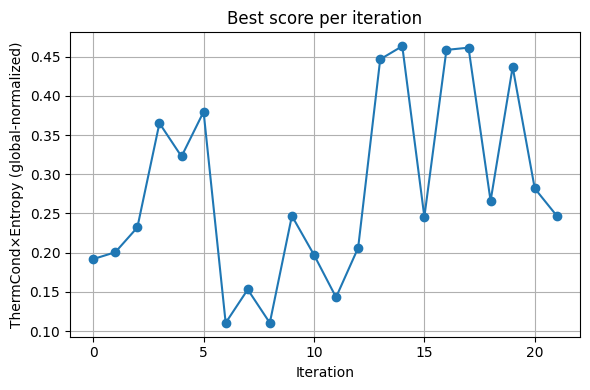

In [ ]:
# Cell 8b: Post-run analysis – best score per iteration and explore/exploit trajectory

import pandas as pd
import matplotlib.pyplot as plt

# 1) Best score per iteration (using logged evaluations)
eval_df = logger.load_evaluations_data()
if not eval_df.empty:
    # Reconstruct Y per iteration and compute best score using score_fn
    # Note: X columns are x_0...x_6 in the generalized logger; Y columns we stored as obj1_name, obj2_name
    # In our setup, logger.log_evaluations stored columns named OBJ1_NAME and OBJ2_NAME.
    obj1_col = OBJ1_NAME
    obj2_col = OBJ2_NAME

    best_scores = {}
    for it, group in eval_df.groupby("iteration"):
        Y_it = group[[obj1_col, obj2_col]].to_numpy()
        scores_it = score_fn(Y_it)
        best_scores[it] = float(scores_it.max())

    print("\n[NB] Best score per iteration (using logged evaluations):")
    for it in sorted(best_scores.keys()):
        print(f"  Iter {it}: best {SCORE_NAME} = {best_scores[it]:.4f}")

    # Optional: quick line plot of best score vs iteration
    its_sorted = sorted(best_scores.keys())
    scores_sorted = [best_scores[it] for it in its_sorted]

    plt.figure(figsize=(6, 4))
    plt.plot(its_sorted, scores_sorted, marker="o")
    plt.xlabel("Iteration")
    plt.ylabel(SCORE_NAME)
    plt.title("Best score per iteration")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("[NB] No evaluation data found; cannot compute best score per iteration.")

In [ ]:
# Explore vs Exploit trajectory from convergence file (stairstep graph)

conv_df = logger.load_convergence_data()

if not conv_df.empty and "selected_n_opt" in conv_df.columns and "selected_n_exp" in conv_df.columns:
    conv_df_sorted = conv_df.sort_values("iteration")

    total_exploit = 0
    total_explore = 0
    traj = []

    # Iteration 0: initial batch
    if 0 in conv_df_sorted["iteration"].values:
        row0 = conv_df_sorted[conv_df_sorted["iteration"] == 0].iloc[0]
        n_opt0 = row0.get("selected_n_opt", 0) or 0
        n_exp0 = row0.get("selected_n_exp", 0) or 0
        total_exploit += int(n_opt0)
        total_explore += int(n_exp0)
        traj.append((0, total_exploit, total_explore))
    else:
        traj.append((0, total_exploit, total_explore))

    # Iterations > 0
    for it, row in conv_df_sorted[conv_df_sorted["iteration"] > 0].iterrows():
        iter_idx = int(row["iteration"])
        n_opt = row.get("selected_n_opt", 0) or 0
        n_exp = row.get("selected_n_exp", 0) or 0

        total_exploit += int(n_opt)
        total_explore += int(n_exp)
        traj.append((iter_idx, total_exploit, total_explore))

    print("\n[NB] Cumulative explored/exploited points per iteration (from convergence):")
    for it, ne, nx in traj:
        print(f"  Iter {it}: explored={ne}, exploited={nx}")

    its_traj, explored_traj, exploited_traj = zip(*traj)

    plt.figure(figsize=(6, 6))
    # Stair‑step style: connect points in order
    plt.plot(explored_traj, exploited_traj, marker="o", linestyle="-", color="C0")

    for it, x_e, x_x in traj:
        plt.text(x_e, x_x, str(it), fontsize=8, ha="center", va="center")

    plt.xlabel("# explored points (cumulative)")
    plt.ylabel("# exploited points (cumulative)")
    plt.title("Explore vs Exploit trajectory (from selected_n_opt/selected_n_exp)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

else:
    print("[NB] Convergence data missing or does not contain selected_n_opt / selected_n_exp.")

ValueError: cannot convert float NaN to integer